# Solar Generation Exploratory Data Analysis

This notebook performs Exploratory Data Analysis (EDA) on a Solar Generation dataset. The objective is to understand the distributions of various features, check for data quality issues, and analyze the relationships between weather features (like Irradiance, Temperature) and the target variable (`AC Power in Watts`).

## 1. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load dataset using relative path for local and GitHub compatibility
df = pd.read_csv("solar_generation.csv")

# Clean any extra spaces in column header names
df.columns = df.columns.str.strip()

df.head()

,MODULE_TEMP,Amb_Temp,WIND_Speed,IRR (W/m2),DC Current in Amps,AC Ir in Amps,AC Iy in Amps,AC Ib in Amps,AC Power in Watts
0,18.7675,17.85190,47.60506,6.388252,0.60,8.6,8.6,8.7,3233
1,18.6150,18.59573,64.26684,12.776500,0.66,9.6,9.7,10.0,4504
2,18.9200,18.59573,85.68912,17.035340,4.74,11.9,12.0,12.4,6614
3,18.9200,18.59573,83.30886,25.553010,8.18,14.8,14.7,14.7,8971
4,19.0725,18.59573,57.12608,36.200090,26.66,18.6,18.4,18.5,12071


## 2. Structural Audit
Let's check the shape, missing values, and data types of the dataset.

In [3]:
print("--- STRUCTURAL AUDIT ---")
print("Dataset Shape (Rows, Columns):", df.shape)
print("\nMissing Values per Column:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)

--- STRUCTURAL AUDIT ---
Dataset Shape (Rows, Columns): (118865, 9)

Missing Values per Column:
 MODULE_TEMP           0
Amb_Temp              0
WIND_Speed            0
IRR (W/m2)            0
DC Current in Amps    0
AC Ir in Amps         0
AC Iy in Amps         0
AC Ib in Amps         0
AC Power in Watts     0
dtype: int64

Data Types:
 MODULE_TEMP           float64
Amb_Temp              float64
WIND_Speed            float64
IRR (W/m2)            float64
DC Current in Amps    float64
AC Ir in Amps         float64
AC Iy in Amps         float64
AC Ib in Amps         float64
AC Power in Watts       int64
dtype: object


## 3. Data Quality & Sanity Checks
Solar generation is highly dependent on daylight. Let's separate daylight records and check for any physical anomalies (e.g., generating power at night, or unphysically high irradiance).

In [4]:
# Filter out nighttime / zero-irradiance readings (IRR <= 5 W/m2)
daylight_df = df[df['IRR (W/m2)'] > 5]

print(f"Total Records: {len(df)}")
print(f"Daylight Records (IRR > 5 W/m2): {len(daylight_df)} ({len(daylight_df)/len(df):.2%})")

# Check for physically impossible irradiance values (Solar constant threshold ~1361 W/m2)
high_irr = df[df['IRR (W/m2)'] > 1361]
print(f"\nUnphysical Irradiance Spikes (>1361 W/m2): {len(high_irr)}")

# Check for non-zero power output during zero irradiance
night_power = df[(df['IRR (W/m2)'] <= 0) & (df['AC Power in Watts'] > 100)]
print(f"Night-time Power Anomalies (IRR <= 0 but Power > 100W): {len(night_power)}")

Total Records: 118865
Daylight Records (IRR > 5 W/m2): 118674 (99.84%)

Unphysical Irradiance Spikes (>1361 W/m2): 17
Night-time Power Anomalies (IRR <= 0 but Power > 100W): 0


## 4. Exploratory Visualizations
Now we'll visualize the data to understand the underlying distributions and relationships, especially focusing on daylight records.

### 4.1 Target Variable Distribution (`AC Power in Watts`)

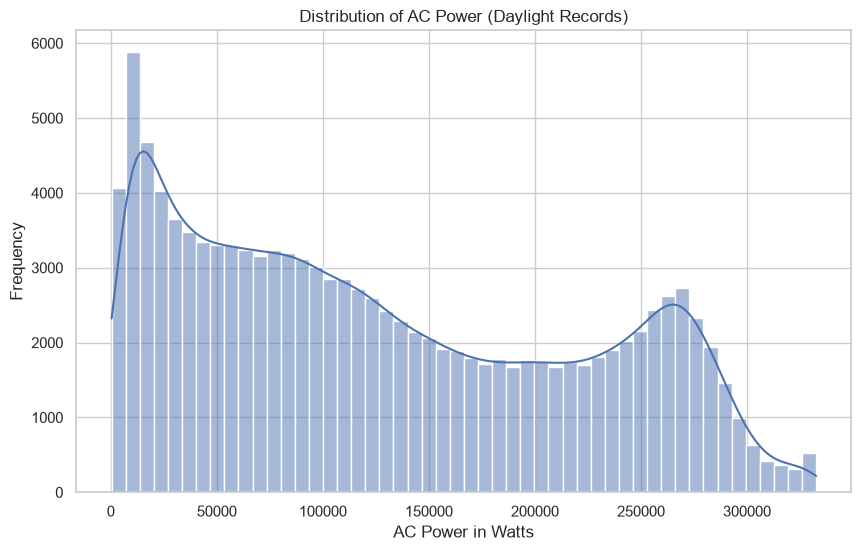

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(daylight_df['AC Power in Watts'], bins=50, kde=True)
plt.title('Distribution of AC Power (Daylight Records)')
plt.xlabel('AC Power in Watts')
plt.ylabel('Frequency')
plt.show()

### 4.2 Feature Relationships (Correlation Heatmap)
We want to see which variables are most strongly correlated with our target variable, AC Power.

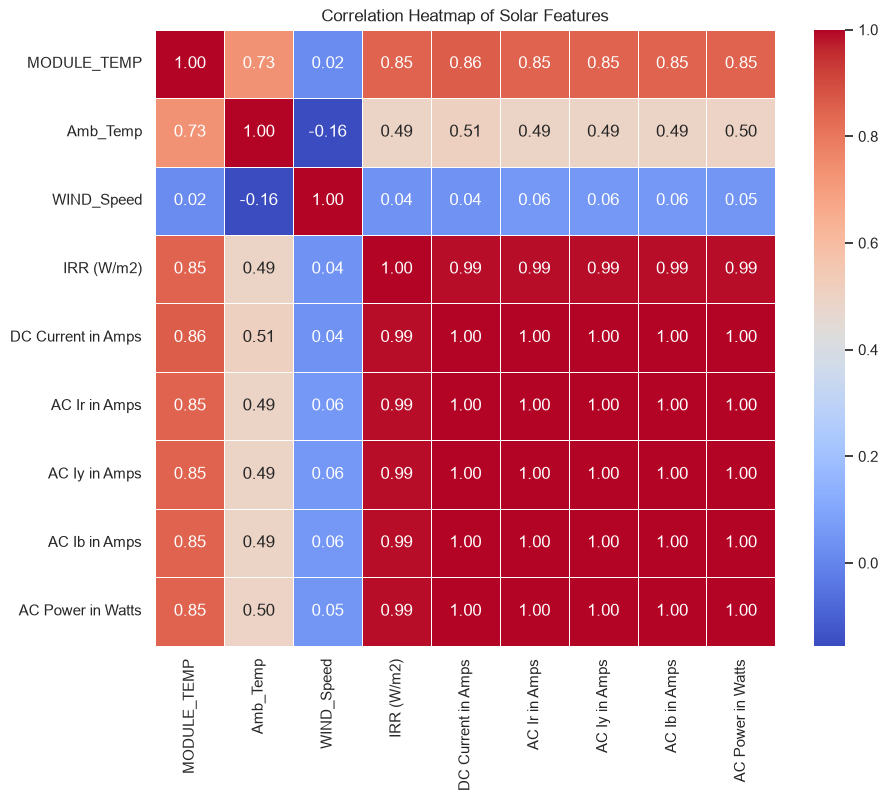

In [6]:
plt.figure(figsize=(10, 8))
corr = daylight_df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Solar Features')
plt.show()

### 4.3 Irradiance vs AC Power
Irradiance should be the strongest predictor of solar power. Let's verify this relationship.

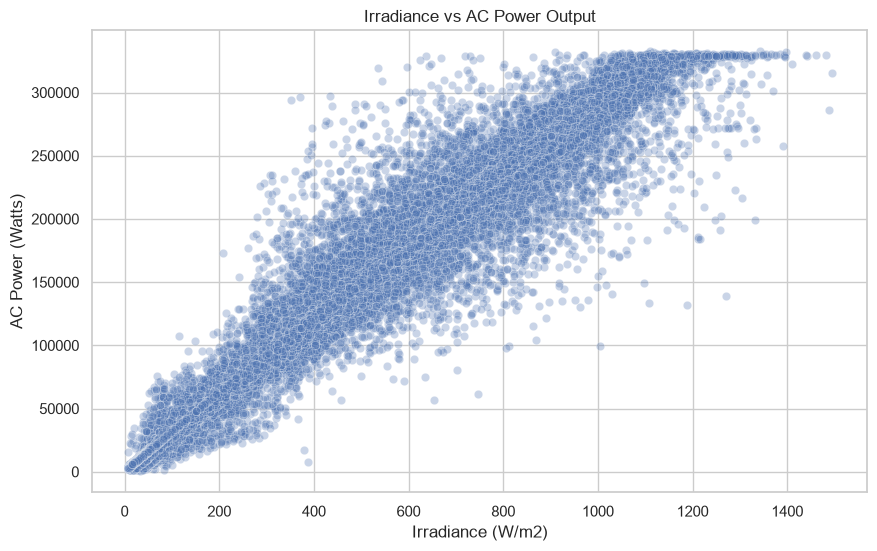

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='IRR (W/m2)', y='AC Power in Watts', data=daylight_df, alpha=0.3)
plt.title('Irradiance vs AC Power Output')
plt.xlabel('Irradiance (W/m2)')
plt.ylabel('AC Power (Watts)')
plt.show()

### 4.4 Temperature Effects
Does ambient temperature or module temperature affect the power output differently? High module temperatures can sometimes decrease efficiency.

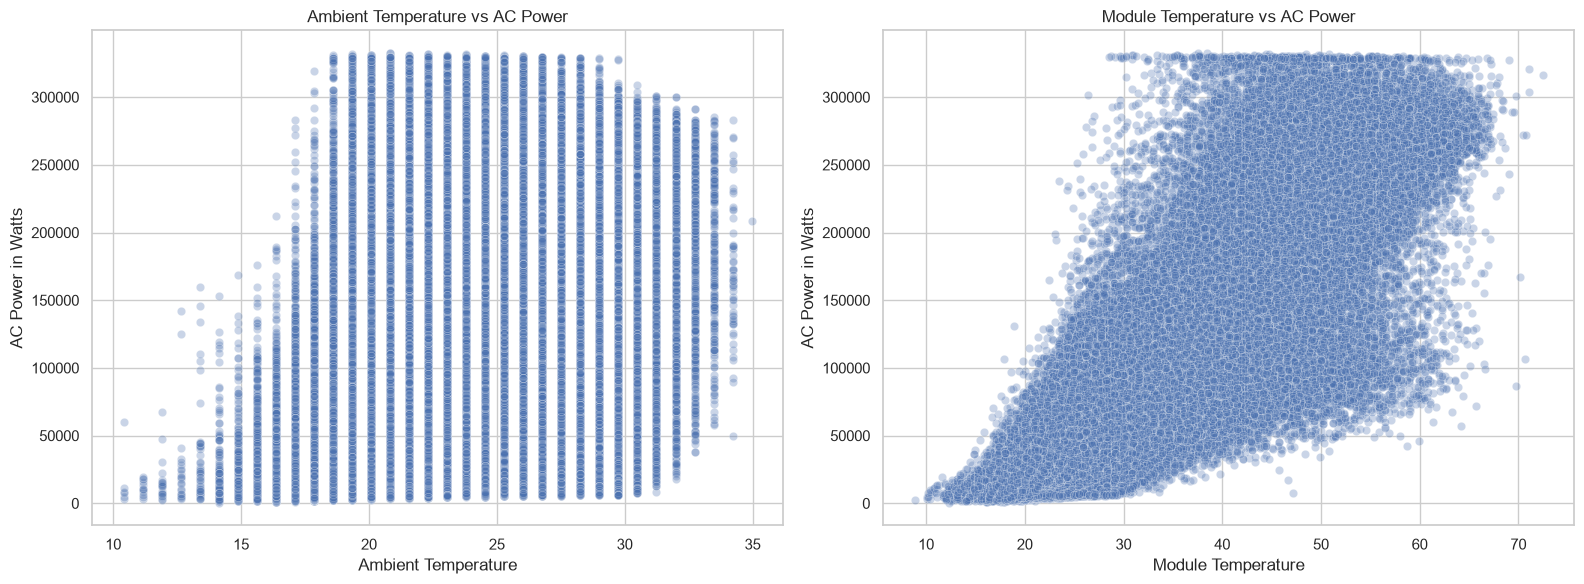

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(x='Amb_Temp', y='AC Power in Watts', data=daylight_df, alpha=0.3, ax=axes[0])
axes[0].set_title('Ambient Temperature vs AC Power')
axes[0].set_xlabel('Ambient Temperature')

sns.scatterplot(x='MODULE_TEMP', y='AC Power in Watts', data=daylight_df, alpha=0.3, ax=axes[1])
axes[1].set_title('Module Temperature vs AC Power')
axes[1].set_xlabel('Module Temperature')

plt.tight_layout()
plt.show()

### 4.5 Multivariate Analysis (Temperature vs Power by Irradiance)

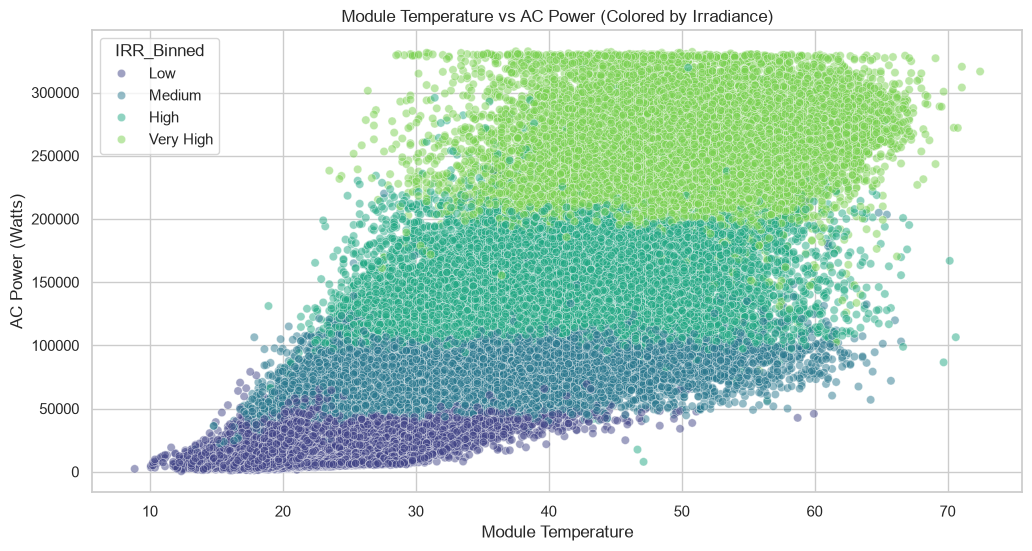

In [9]:
import warnings
warnings.filterwarnings('ignore')

plt.figure(figsize=(12, 6))
# Create a binned version of Irradiance for better coloring
daylight_df = daylight_df.copy() # Avoid SettingWithCopyWarning
daylight_df['IRR_Binned'] = pd.qcut(daylight_df['IRR (W/m2)'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
sns.scatterplot(x='MODULE_TEMP', y='AC Power in Watts', hue='IRR_Binned', data=daylight_df, alpha=0.5, palette='viridis')
plt.title('Module Temperature vs AC Power (Colored by Irradiance)')
plt.xlabel('Module Temperature')
plt.ylabel('AC Power (Watts)')
plt.show()

### 4.6 Feature Distributions
Check the shape of the data for skewness or anomalies.

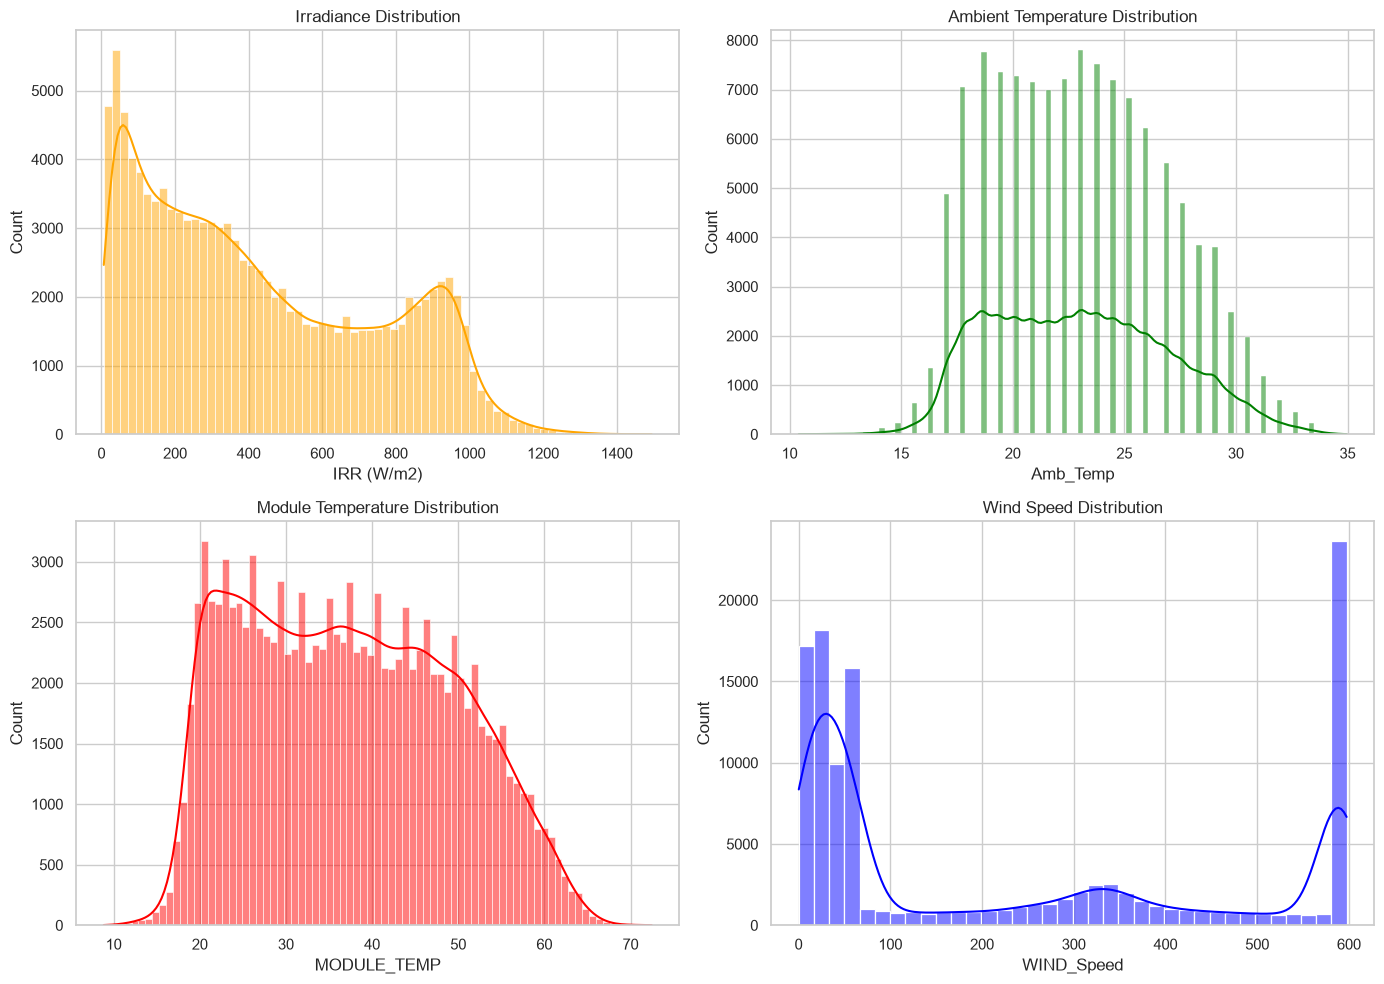

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Using explicit bins arrays for numpy 2.x compatibility / bugs if needed, or 'auto'
sns.histplot(daylight_df['IRR (W/m2)'].dropna(), bins='auto', kde=True, ax=axes[0,0], color='orange')
axes[0,0].set_title('Irradiance Distribution')

sns.histplot(daylight_df['Amb_Temp'].dropna(), bins='auto', kde=True, ax=axes[0,1], color='green')
axes[0,1].set_title('Ambient Temperature Distribution')

sns.histplot(daylight_df['MODULE_TEMP'].dropna(), bins='auto', kde=True, ax=axes[1,0], color='red')
axes[1,0].set_title('Module Temperature Distribution')

sns.histplot(daylight_df['WIND_Speed'].dropna(), bins='auto', kde=True, ax=axes[1,1], color='blue')
axes[1,1].set_title('Wind Speed Distribution')
plt.tight_layout()
plt.show()

### 4.7 Outlier Detection (Boxplots)
Identifying statistical outliers in the numeric features.

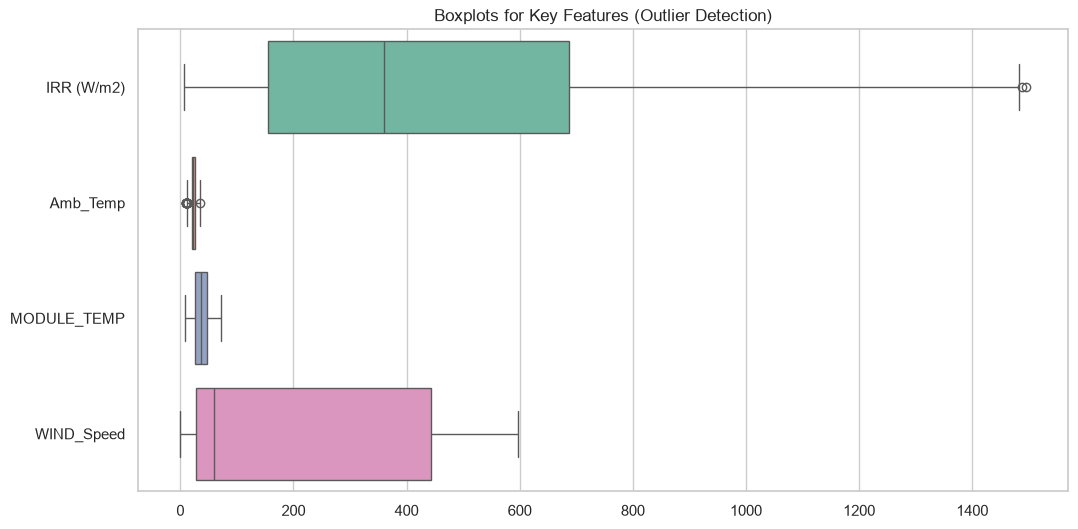

In [11]:
features_to_plot = ['IRR (W/m2)', 'Amb_Temp', 'MODULE_TEMP', 'WIND_Speed']
plt.figure(figsize=(12, 6))
sns.boxplot(data=daylight_df[features_to_plot], orient='h', palette='Set2')
plt.title('Boxplots for Key Features (Outlier Detection)')
plt.show()

### 4.8 Feature Engineering (Temperature Difference & Efficiency)
Creating new features that might be powerful predictors for machine learning.

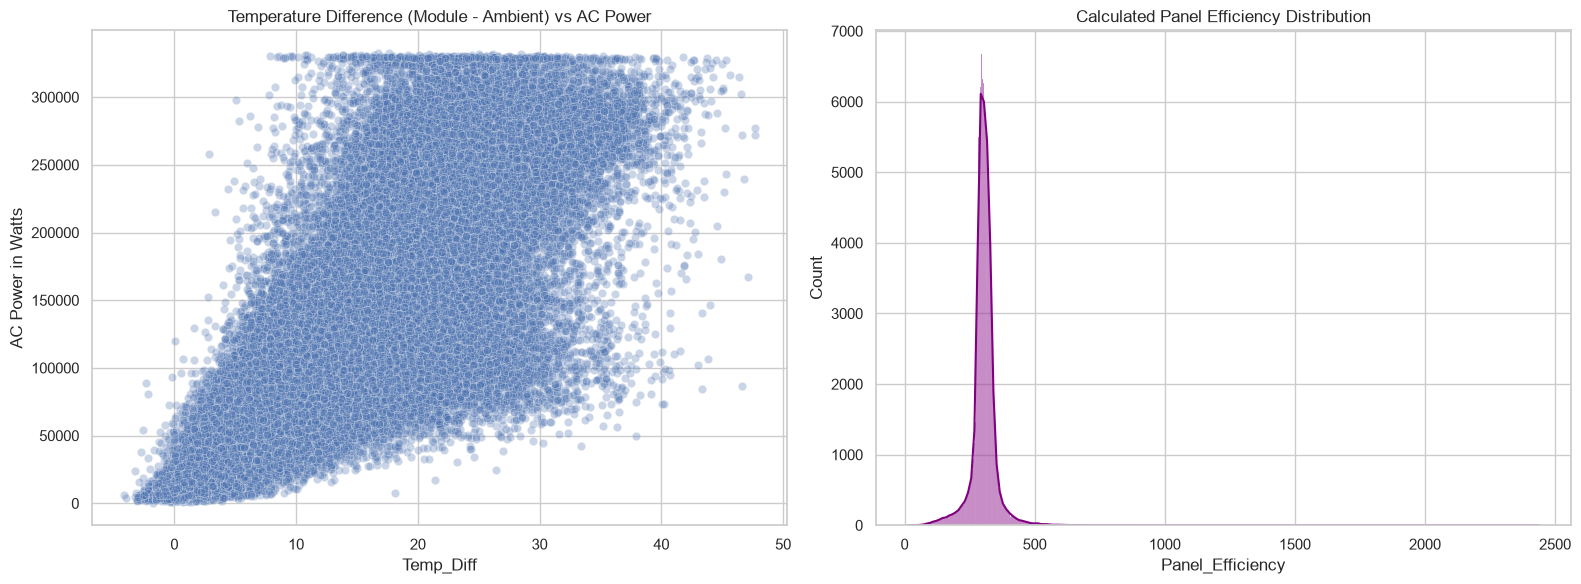

In [12]:
# Create new features
daylight_df['Temp_Diff'] = daylight_df['MODULE_TEMP'] - daylight_df['Amb_Temp']
daylight_df['Panel_Efficiency'] = daylight_df['AC Power in Watts'] / daylight_df['IRR (W/m2)']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(x='Temp_Diff', y='AC Power in Watts', data=daylight_df, alpha=0.3, ax=axes[0])
axes[0].set_title('Temperature Difference (Module - Ambient) vs AC Power')

# Plot efficiency distribution, dropping infinities if IRR was very close to 0
sns.histplot(daylight_df['Panel_Efficiency'].replace([np.inf, -np.inf], np.nan).dropna(), bins='auto', kde=True, ax=axes[1], color='purple')
axes[1].set_title('Calculated Panel Efficiency Distribution')
plt.tight_layout()
plt.show()

## 5. Conclusion
- The dataset has been validated for structural integrity (no missing values in key columns).
- We filtered out non-generating night hours for more accurate modeling.
- Irradiance has a strong positive linear correlation with AC Power.
- Temperature effects are present and should be considered during modeling. High module temps at equivalent irradiance levels can reduce efficiency.
- Explored feature distributions and found [add your observations on skewness here].
- Boxplots highlight statistical outliers in Wind Speed and Temperature that may need scaling or clipping.
- Engineered new features (`Temp_Diff` and `Panel_Efficiency`) which reveal more nuanced relationships and panel performance metrics.
- Note: Lack of timestamp data prevents time-series or seasonal analysis, meaning predictions rely purely on instantaneous weather conditions.